## Import needed libraries

In [1]:
import sys
import pandas as pd
import torch
from torch import nn 
import matplotlib.pyplot as plt

## Read and view the data

In [2]:
# Pandas: Reading the data
df = pd.read_csv("./data/used_cars.csv")  
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Clean the data

In [3]:
# FEATURES:
# Compute how old the car is
age = df["model_year"].max() - df["model_year"]

# Turn milage to an int
milage = df["milage"]
milage = milage.str.replace(",", "")
milage = milage.str.replace(" mi.", "")
milage = milage.astype(int)

# Turn accident_free into a bool
accident_free = df["accident"] == "None reported" 
accident_free.astype(int)

# LABLES:
# Turn price into an int
price = df["price"]
price = price.str.replace("$", "")
price = price.str.replace(",", "")
price = price.astype(int) 

# Note that we will use these 3 as features to our modle

## Normalize the data

In [4]:
# Save our features as columns of tensors
X = torch.column_stack([
    torch.tensor(age, dtype=torch.float32),
    torch.tensor(milage, dtype=torch.float32),
    torch.tensor(accident_free, dtype=torch.float32)
])

# Our feature matrix looks like this:
#     [
#       [5, 10000, 1],
#       [2, 30000, 0],
#       [6, 20000, 1]
#     ]

# Compute sample statistics for our features and normalize using z-scores
# We use axis=0 to compute means/stds by column (feature-wise)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std  # z-score formula: (x - mean) / std

# Save our labels as a column tensor
y = torch.tensor(price, dtype=torch.float32).reshape((-1, 1))
# -1 lets PyTorch figure out the number of rows automatically
# 1 forces it to be a single column

# Our labels look like this:
#     [
#       [15000.],
#       [20000.],
#       [25000.]
#     ]

# Compute sample statistics for our labels and normalize using z-scores
# We don’t need axis=0 here since y has only one column
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std

## Train the Modle (Neural Network)

0.9090433120727539


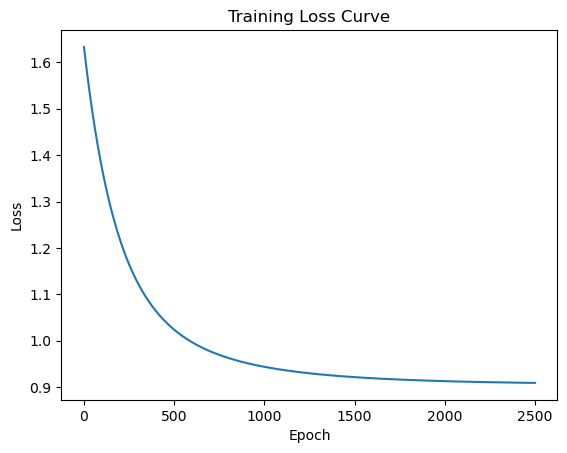

In [5]:
# Train a simple 1 layer NN 
# We should have 3 inputs (age, mialge, and accident_free)
model = nn.Linear(3, 1)

# We are going to use MSE (Mean Squared Error) loss to evaluate our modle 
# This is because MSE penalizes larger errors more than smaller ones
loss_fn = torch.nn.MSELoss()

# The optimizer (tells modle how change weights)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001) 

# Basic Traig loop:
# Model → makes predictions (with weights we want to learn).
# Loss function → measures how wrong the predictions are.
# Optimizer → updates the weights to reduce the loss.

# Train with 2500 iterations 
epochs = 2500  

# Save the losses to plot 
losses = [] 

for i in range(0, epochs):
    optimizer.zero_grad()      # 1. Reset gradients (slopes of the loss wrt each weight), since Pytorch accumlates them each iteration
    outputs = model(X)         # 2. Forward pass predict, ie run the modle and see what the predictions is
    loss = loss_fn(outputs, y) # 3. Compute loss, ie how wrong was our prediction using the loss function 
    loss.backward()            # 4. Backward pass, compute gradients of the loss wrt model parameters (backpropagation).
    optimizer.step()           # 5. Update weights, optimizer adjusts the model parameters using the gradients. 

    losses.append(loss.item())
    
# Plot the losses  
print(losses[-1])
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Use Modle to make a Prediction

In [6]:
# Input some dummy data
X_data = torch.tensor([
    [5, 10000, 1],
    [2, 10000, 1],
    [5, 20000, 1]
], dtype=torch.float32)  


# Data Explained
# Car 1: age 5, milage 10,000, accident_free= yes
# Car 2: age 2, milage 10,000, accident_free= no
# Car 3: age 5, milage 20,000, accident_free= yes


# Input normalized data using z-scores
prediction = model((X_data - X_mean) / X_std) 

# De-normalize the data so we can make sense of it
print(prediction * y_std + y_mean) 

tensor([[72134.3359],
        [70372.7500],
        [66757.5703]], grad_fn=<AddBackward0>)
